<a href="https://colab.research.google.com/github/HowardHNguyen/Data_Science_for_Marketing_Solutions/blob/main/retail_pseudo_ab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retail pseudo-A/B simulations

A/A checks and simulated A/B tests using historical retail sales. These test the analysis pipeline, not actual discount effects. Run all cells in Google Colab. The cohort is retrospectively restricted to products with purchases in all 16 weeks; this is not a prospective eligibility rule.

The outcome is log post/pre mean weekly units. The percentage contrast is a ratio of geometric product growth factors, not a difference in total retailer sales. Treatment is randomly assigned by product, with a homogeneous hypothetical uplift and no simulated spillovers. Intervals assume the chosen independent product randomization; real pricing policies may require a different unit.


In [1]:
%pip -q install openpyxl
import pandas as pd
from google.colab import drive
drive.mount("/content/drive")
data = pd.read_excel("/content/drive/MyDrive/data/online_retail_uci.xlsx", engine="openpyxl", dtype={"StockCode": "string", "InvoiceNo": "string"})


Mounted at /content/drive


In [2]:
"""Run after loading the retail workbook into the pandas DataFrame `data`.
All treatment effects below are simulated, not measured pricing effects.
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statistics import NormalDist
from math import erfc, sqrt



In [3]:
# 1. Freeze a historical simulation cohort.
# Complete coverage uses historical outcome availability. This is a retrospective
# benchmark, NOT a prospective experiment eligibility rule or all-product sample.
PRE_START = pd.Timestamp('2011-04-04')
POST_START = pd.Timestamp('2011-05-30')
END = pd.Timestamp('2011-07-25')  # exclusive: eight weeks before and after
N_SIM = 1000
SEED = 42

d = data.copy()
d['InvoiceDate'] = pd.to_datetime(d['InvoiceDate'], errors='coerce')
d['StockCode'] = d['StockCode'].astype('string').str.strip()
invoice = d['InvoiceNo'].astype('string').str.upper()
for col in ['Quantity', 'UnitPrice']:
    d[col] = pd.to_numeric(d[col], errors='coerce')
keep = (
    d['Country'].eq('United Kingdom')
    & ~invoice.str.startswith('C', na=False)
    & d['StockCode'].str.fullmatch(r'\d{5}[A-Za-z]*', na=False)
    & d['Quantity'].gt(0) & d['UnitPrice'].gt(0)
    & np.isfinite(d['Quantity']) & np.isfinite(d['UnitPrice'])
    & d['InvoiceDate'].ge(PRE_START) & d['InvoiceDate'].lt(END)
)
sales = d.loc[keep].copy()
sales['week'] = sales['InvoiceDate'].dt.to_period('W-SUN').dt.start_time
weeks = pd.date_range(PRE_START, END - pd.Timedelta(weeks=1), freq='W-MON')
units = sales.groupby(['StockCode', 'week'])['Quantity'].sum().unstack()
units = units.reindex(columns=weeks)
total_products = len(units)
units = units.loc[units.notna().all(axis=1) & units.gt(0).all(axis=1)]
assert len(units) >= 40, 'Too few fully observed products for this example.'

# No missing product-week is filled with zero. Gross positive units exclude returns.
pre = units.loc[:, units.columns < POST_START].mean(axis=1).to_numpy()
post = units.loc[:, units.columns >= POST_START].mean(axis=1).to_numpy()
baseline_growth = np.log(post / pre)
n = len(baseline_growth)
print(f'Historical cohort: {n:,} of {total_products:,} products; {len(weeks)} weeks.')



Historical cohort: 524 of 3,200 products; 16 weeks.


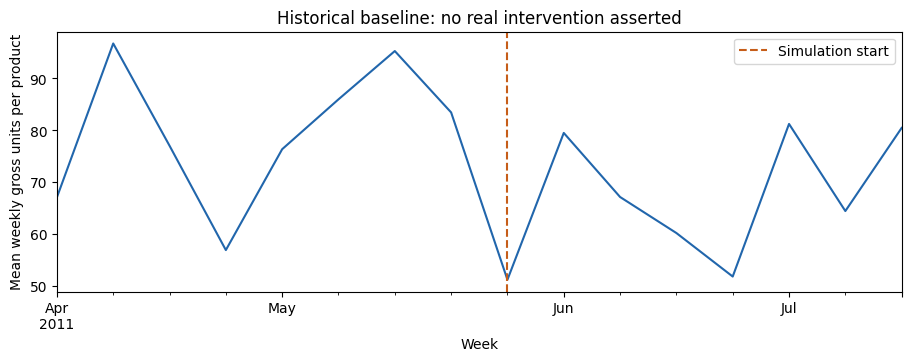

In [4]:
# 2. Illustrate historical trends. The vertical line is a SIMULATED start date.
fig, ax = plt.subplots(figsize=(9, 3.5), layout='constrained')
units.mean(axis=0).plot(ax=ax, color='#2166ac')
ax.axvline(POST_START, color='#c65d19', linestyle='--', label='Simulation start')
ax.set(title='Historical baseline: no real intervention asserted',
       xlabel='Week', ylabel='Mean weekly gross units per product')
ax.legend()
plt.show()



In [5]:
# 3. A product is the randomization AND analysis unit, not an invoice line.
# Outcome: log(post-period mean units / pre-period mean units).
# Multiplying B's post sales by 1+uplift adds log(1+uplift) to this outcome.
# Large-sample unequal-variance normal intervals are approximate.
# Reassignment evaluates their calibration for this historical cohort.
def evaluate(outcome, treatment):
    b, a = outcome[treatment], outcome[~treatment]
    estimate = b.mean() - a.mean()
    vb, va = b.var(ddof=1) / len(b), a.var(ddof=1) / len(a)
    se = np.sqrt(vb + va)
    critical = NormalDist().inv_cdf(.975)
    low, high = estimate - critical*se, estimate + critical*se
    p_value = erfc(abs(estimate / se) / sqrt(2))
    return estimate, low, high, p_value

rng = np.random.default_rng(SEED)
# Reuse assignments across scenarios for a fair simulation comparison.
assignments = np.zeros((N_SIM, n), dtype=bool)
for assignment in assignments:
    assignment[rng.permutation(n)[:n//2]] = True

records = []
for uplift in [0.00, 0.05, 0.10, 0.20]:
    true_log_effect = np.log1p(uplift)
    for run, treatment in enumerate(assignments):
        simulated_growth = baseline_growth + treatment * true_log_effect
        estimate, low, high, p_value = evaluate(simulated_growth, treatment)
        records.append({
            'uplift': uplift, 'run': run, 'estimate_log': estimate,
            'low_log': low, 'high_log': high, 'p_value': p_value,
            'covered': low <= true_log_effect <= high,
            'true_log_effect': true_log_effect,
        })
results = pd.DataFrame(records)
results['reject'] = results['p_value'] < .05
results['error_log'] = results['estimate_log'] - results['true_log_effect']
summary = results.groupby('uplift').agg(
    rejection_rate=('reject', 'mean'), coverage=('covered', 'mean'),
    bias_log=('error_log', 'mean'), mean_estimate_log=('estimate_log', 'mean'))
summary['rejection_MC_SE'] = np.sqrt(summary.rejection_rate * (1-summary.rejection_rate) / N_SIM)
summary['recovered_percent'] = 100 * np.expm1(summary.mean_estimate_log)
print('\nZero uplift: rejection rate = false-positive rate. Other rows: simulated power.')
print(summary.round(4).to_string())




Zero uplift: rejection rate = false-positive rate. Other rows: simulated power.
        rejection_rate  coverage  bias_log  mean_estimate_log  rejection_MC_SE  recovered_percent
uplift                                                                                           
0.00             0.050      0.95   -0.0009            -0.0009           0.0069            -0.0946
0.05             0.182      0.95   -0.0009             0.0478           0.0122             4.9007
0.10             0.528      0.95   -0.0009             0.0944           0.0158             9.8959
0.20             0.980      0.95   -0.0009             0.1814           0.0044            19.8865


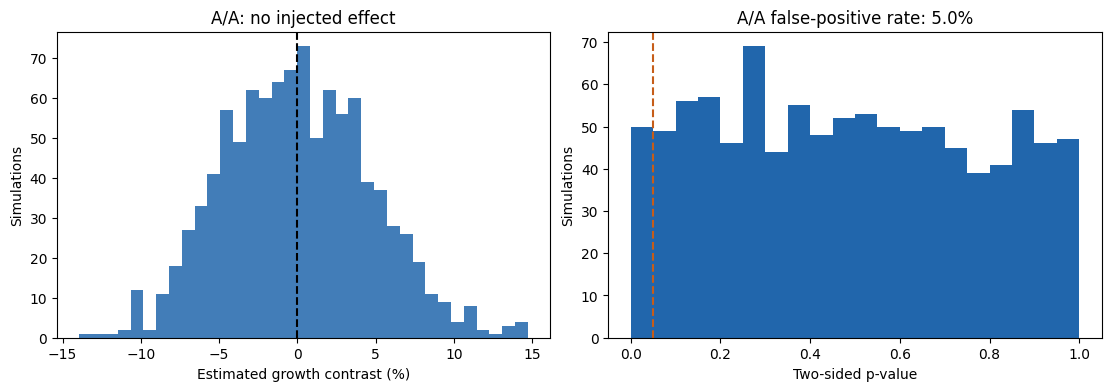

In [6]:
# 4. A/A diagnostics: estimates should center near 0, not all equal 0.
aa = results.loc[results.uplift.eq(0)]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout='constrained')
axes[0].hist(100*np.expm1(aa.estimate_log), bins=35, color='#2166ac', alpha=.85)
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set(title='A/A: no injected effect', xlabel='Estimated growth contrast (%)', ylabel='Simulations')
axes[1].hist(aa.p_value, bins=np.linspace(0,1,21), color='#2166ac')
axes[1].axvline(.05, color='#c65d19', linestyle='--')
axes[1].set(title=f'A/A false-positive rate: {aa.reject.mean():.1%}', xlabel='Two-sided p-value', ylabel='Simulations')
plt.show()



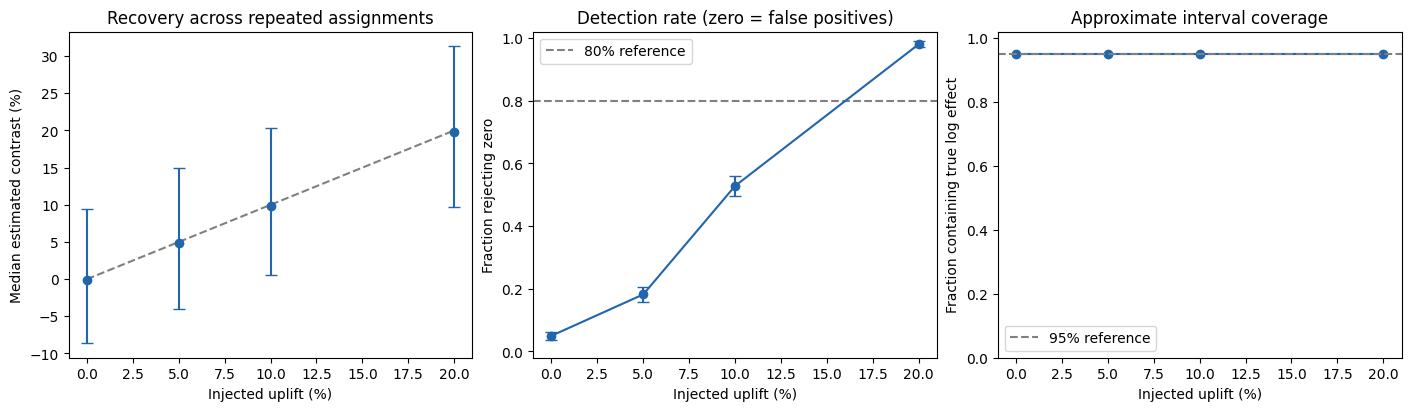


Recovery bars are the central 95% of SIMULATION estimates, not one experiment’s confidence interval.
Detection bars show approximate Monte Carlo uncertainty; 1,000 repeats are not 1,000 new datasets.
Conclusions apply to this frozen cohort, homogeneous injected effects and randomization scheme.
No actual discount was applied. This cannot establish the causal effect of a real price reduction.


In [7]:
# 5. Effect recovery, detection rates and interval coverage.
fig, axes = plt.subplots(1, 3, figsize=(14, 4), layout='constrained')
for uplift, g in results.groupby('uplift'):
    q = 100*np.expm1(g.estimate_log.quantile([.025,.5,.975]).to_numpy())
    axes[0].errorbar(100*uplift, q[1], yerr=[[q[1]-q[0]], [q[2]-q[1]]],
                    fmt='o', capsize=4, color='#2166ac')
axes[0].plot([0,20],[0,20], linestyle='--', color='gray')
axes[0].set(title='Recovery across repeated assignments', xlabel='Injected uplift (%)',
            ylabel='Median estimated contrast (%)')
axes[1].errorbar(100*summary.index, summary.rejection_rate,
                yerr=1.96*summary.rejection_MC_SE, fmt='o-', color='#2166ac', capsize=4)
axes[1].axhline(.8,color='gray',linestyle='--',label='80% reference')
axes[1].set(title='Detection rate (zero = false positives)', xlabel='Injected uplift (%)', ylabel='Fraction rejecting zero', ylim=(-.02,1.02))
axes[1].legend()
axes[2].plot(100*summary.index,summary.coverage,'o-',color='#2166ac')
axes[2].axhline(.95,color='gray',linestyle='--',label='95% reference')
axes[2].set(title='Approximate interval coverage', xlabel='Injected uplift (%)', ylabel='Fraction containing true log effect', ylim=(0,1.02))
axes[2].legend()
plt.show()
print('\nRecovery bars are the central 95% of SIMULATION estimates, not one experiment’s confidence interval.')
print('Detection bars show approximate Monte Carlo uncertainty; 1,000 repeats are not 1,000 new datasets.')
print('Conclusions apply to this frozen cohort, homogeneous injected effects and randomization scheme.')
print('No actual discount was applied. This cannot establish the causal effect of a real price reduction.')
summary.to_csv('pseudo_ab_summary.csv', index_label='injected_uplift')


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t as student_t

In [10]:
# 1. Freeze a historical simulation cohort.
# Complete coverage uses historical outcome availability. This is a retrospective
# benchmark, NOT a prospective experiment eligibility rule or all-product sample.
PRE_START = pd.Timestamp('2011-04-04')
POST_START = pd.Timestamp('2011-05-30')
END = pd.Timestamp('2011-07-25')  # exclusive: eight weeks before and after
N_SIM = 1000
SEED = 42

In [11]:
d = data.copy()
d['InvoiceDate'] = pd.to_datetime(d['InvoiceDate'], errors='coerce')
d['StockCode'] = d['StockCode'].astype('string').str.strip()
invoice = d['InvoiceNo'].astype('string').str.upper()
for col in ['Quantity', 'UnitPrice']:
    d[col] = pd.to_numeric(d[col], errors='coerce')
keep = (
    d['Country'].eq('United Kingdom')
    & ~invoice.str.startswith('C', na=False)
    & d['StockCode'].str.fullmatch(r'\d{5}[A-Za-z]*', na=False)
    & d['Quantity'].gt(0) & d['UnitPrice'].gt(0)
    & np.isfinite(d['Quantity']) & np.isfinite(d['UnitPrice'])
    & d['InvoiceDate'].ge(PRE_START) & d['InvoiceDate'].lt(END)
)
sales = d.loc[keep].copy()
sales['week'] = sales['InvoiceDate'].dt.to_period('W-SUN').dt.start_time
weeks = pd.date_range(PRE_START, END - pd.Timedelta(weeks=1), freq='W-MON')
units = sales.groupby(['StockCode', 'week'])['Quantity'].sum().unstack()
units = units.reindex(columns=weeks)
total_products = len(units)
units = units.loc[units.notna().all(axis=1) & units.gt(0).all(axis=1)]
assert len(units) >= 40, 'Too few fully observed products for this example.'

In [12]:
# No missing product-week is filled with zero. Gross positive units exclude returns.
pre = units.loc[:, units.columns < POST_START].mean(axis=1).to_numpy()
post = units.loc[:, units.columns >= POST_START].mean(axis=1).to_numpy()
baseline_growth = np.log(post / pre)
n = len(baseline_growth)
print(f'Historical cohort: {n:,} of {total_products:,} products; {len(weeks)} weeks.')

Historical cohort: 524 of 3,200 products; 16 weeks.


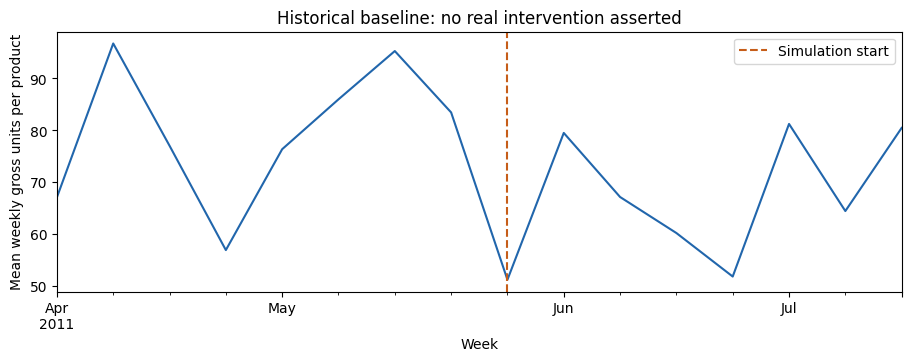

In [13]:
# 2. Illustrate historical trends. The vertical line is a SIMULATED start date.
fig, ax = plt.subplots(figsize=(9, 3.5), layout='constrained')
units.mean(axis=0).plot(ax=ax, color='#2166ac')
ax.axvline(POST_START, color='#c65d19', linestyle='--', label='Simulation start')
ax.set(title='Historical baseline: no real intervention asserted',
       xlabel='Week', ylabel='Mean weekly gross units per product')
ax.legend()
plt.show()

In [14]:
# 3. A product is the randomization AND analysis unit, not an invoice line.
# Outcome: log(post-period mean units / pre-period mean units).
# Multiplying B's post sales by 1+uplift adds log(1+uplift) to this outcome.
# Welch intervals are approximate. Reassignment evaluates their calibration here.
def evaluate(outcome, treatment):
    b, a = outcome[treatment], outcome[~treatment]
    estimate = b.mean() - a.mean()
    vb, va = b.var(ddof=1) / len(b), a.var(ddof=1) / len(a)
    se = np.sqrt(vb + va)
    df = (vb + va)**2 / (vb**2 / (len(b)-1) + va**2 / (len(a)-1))
    critical = student_t.ppf(.975, df)
    low, high = estimate - critical*se, estimate + critical*se
    p_value = 2 * student_t.sf(abs(estimate / se), df)
    return estimate, low, high, p_value

rng = np.random.default_rng(SEED)
# Reuse assignments across scenarios for a fair simulation comparison.
assignments = np.zeros((N_SIM, n), dtype=bool)
for assignment in assignments:
    assignment[rng.permutation(n)[:n//2]] = True

records = []
for uplift in [0.00, 0.05, 0.10, 0.20]:
    true_log_effect = np.log1p(uplift)
    for run, treatment in enumerate(assignments):
        simulated_growth = baseline_growth + treatment * true_log_effect
        estimate, low, high, p_value = evaluate(simulated_growth, treatment)
        records.append({
            'uplift': uplift, 'run': run, 'estimate_log': estimate,
            'low_log': low, 'high_log': high, 'p_value': p_value,
            'covered': low <= true_log_effect <= high,
            'true_log_effect': true_log_effect,
        })
results = pd.DataFrame(records)
results['reject'] = results['p_value'] < .05
results['error_log'] = results['estimate_log'] - results['true_log_effect']
summary = results.groupby('uplift').agg(
    rejection_rate=('reject', 'mean'), coverage=('covered', 'mean'),
    bias_log=('error_log', 'mean'), mean_estimate_log=('estimate_log', 'mean'))
summary['rejection_MC_SE'] = np.sqrt(summary.rejection_rate * (1-summary.rejection_rate) / N_SIM)
summary['recovered_percent'] = 100 * np.expm1(summary.mean_estimate_log)
print('\nZero uplift: rejection rate = false-positive rate. Other rows: simulated power.')
print(summary.round(4).to_string())


Zero uplift: rejection rate = false-positive rate. Other rows: simulated power.
        rejection_rate  coverage  bias_log  mean_estimate_log  rejection_MC_SE  recovered_percent
uplift                                                                                           
0.00             0.050      0.95   -0.0009            -0.0009           0.0069            -0.0946
0.05             0.182      0.95   -0.0009             0.0478           0.0122             4.9007
0.10             0.527      0.95   -0.0009             0.0944           0.0158             9.8959
0.20             0.979      0.95   -0.0009             0.1814           0.0045            19.8865


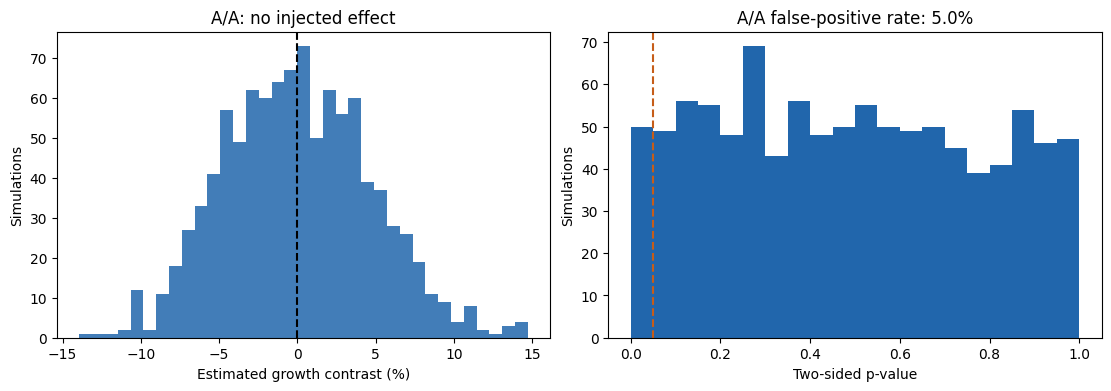

In [15]:
# 4. A/A diagnostics: estimates should center near 0, not all equal 0.
aa = results.loc[results.uplift.eq(0)]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), layout='constrained')
axes[0].hist(100*np.expm1(aa.estimate_log), bins=35, color='#2166ac', alpha=.85)
axes[0].axvline(0, color='black', linestyle='--')
axes[0].set(title='A/A: no injected effect', xlabel='Estimated growth contrast (%)', ylabel='Simulations')
axes[1].hist(aa.p_value, bins=np.linspace(0,1,21), color='#2166ac')
axes[1].axvline(.05, color='#c65d19', linestyle='--')
axes[1].set(title=f'A/A false-positive rate: {aa.reject.mean():.1%}', xlabel='Two-sided p-value', ylabel='Simulations')
plt.show()

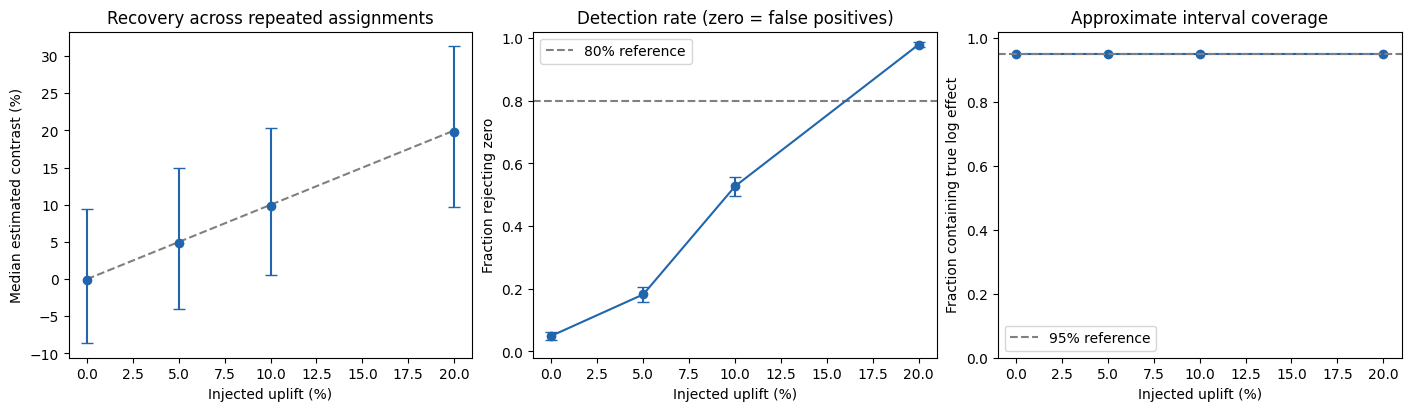


Recovery bars are the central 95% of SIMULATION estimates, not one experiment’s confidence interval.
Detection bars show approximate Monte Carlo uncertainty; 1,000 repeats are not 1,000 new datasets.
Conclusions apply to this frozen cohort, homogeneous injected effects and randomization scheme.
No actual discount was applied. This cannot establish the causal effect of a real price reduction.


In [16]:
# 5. Effect recovery, detection rates and interval coverage.
fig, axes = plt.subplots(1, 3, figsize=(14, 4), layout='constrained')
for uplift, g in results.groupby('uplift'):
    q = 100*np.expm1(g.estimate_log.quantile([.025,.5,.975]).to_numpy())
    axes[0].errorbar(100*uplift, q[1], yerr=[[q[1]-q[0]], [q[2]-q[1]]],
                    fmt='o', capsize=4, color='#2166ac')
axes[0].plot([0,20],[0,20], linestyle='--', color='gray')
axes[0].set(title='Recovery across repeated assignments', xlabel='Injected uplift (%)',
            ylabel='Median estimated contrast (%)')
axes[1].errorbar(100*summary.index, summary.rejection_rate,
                yerr=1.96*summary.rejection_MC_SE, fmt='o-', color='#2166ac', capsize=4)
axes[1].axhline(.8,color='gray',linestyle='--',label='80% reference')
axes[1].set(title='Detection rate (zero = false positives)', xlabel='Injected uplift (%)', ylabel='Fraction rejecting zero', ylim=(-.02,1.02))
axes[1].legend()
axes[2].plot(100*summary.index,summary.coverage,'o-',color='#2166ac')
axes[2].axhline(.95,color='gray',linestyle='--',label='95% reference')
axes[2].set(title='Approximate interval coverage', xlabel='Injected uplift (%)', ylabel='Fraction containing true log effect', ylim=(0,1.02))
axes[2].legend()
plt.show()
print('\nRecovery bars are the central 95% of SIMULATION estimates, not one experiment’s confidence interval.')
print('Detection bars show approximate Monte Carlo uncertainty; 1,000 repeats are not 1,000 new datasets.')
print('Conclusions apply to this frozen cohort, homogeneous injected effects and randomization scheme.')
print('No actual discount was applied. This cannot establish the causal effect of a real price reduction.')
summary.to_csv('pseudo_ab_summary.csv', index_label='injected_uplift')